In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
DATA_DIR_FILENAME = Path("/home/nbyrnes/code/random-matrix/paper_data/data")
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids_rectangular.pkl"
)
TWO_NP_PREAMBLE = "2d_np_rectangular_midpoint_"
THREE_NP_PREAMBLE = "3d_np_rectangular_midpoint_"
TWO_CP_PREAMBLE = "2d_cp_rectangular_midpoint_"
THREE_CP_PREAMBLE = "3d_cp_rectangular_midpoint_"

if MODE_GRIDS_FILENAME.exists():
    # Load existing mode grids
    with MODE_GRIDS_FILENAME.open("rb") as f:
        mode_grids = pickle.load(f)
        num_modes = [m.num_propagating for m in mode_grids]

two_np_paths = [
    DATA_DIR_FILENAME / f"{TWO_NP_PREAMBLE}{n}/integration_time.pkl"
    for n in num_modes
]
three_np_paths = [
    DATA_DIR_FILENAME / f"{THREE_NP_PREAMBLE}{n}/integration_time.pkl"
    for n in num_modes
]
two_cp_paths = [
    DATA_DIR_FILENAME / f"{TWO_CP_PREAMBLE}{n}/integration_time.pkl"
    for n in num_modes
]
three_cp_paths = [
    DATA_DIR_FILENAME / f"{THREE_CP_PREAMBLE}{n}/integration_time.pkl"
    for n in num_modes
]

two_np_times = []
three_np_times = []
two_cp_times = []
three_cp_times = []

for p in two_np_paths:
    if p.exists():
        with p.open("rb") as f:
            time = pickle.load(f)
            two_np_times.append(time)
for p in three_np_paths:
    if p.exists():
        with p.open("rb") as f:
            time = pickle.load(f)
            three_np_times.append(time)
for p in two_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            time = pickle.load(f)
            two_cp_times.append(time)
for p in three_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            time = pickle.load(f)
            three_cp_times.append(time)

In [3]:
print(len(two_np_times))
print(len(three_np_times))

9
8


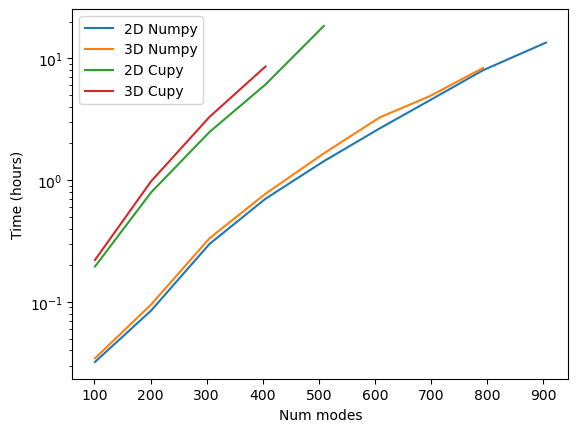

In [4]:
end_index_two_np = len(two_np_times)
end_index_three_np = len(three_np_times)
end_index_two_cp = len(two_cp_times)
end_index_three_cp = len(three_cp_times)

fig, ax = plt.subplots()

ax.plot(
    np.array(num_modes)[:end_index_two_np],
    np.array(two_np_times) / 60**2,
    label="2D Numpy",
)
ax.plot(
    np.array(num_modes)[:end_index_three_np],
    np.array(three_np_times) / 60**2,
    label="3D Numpy",
)
ax.plot(
    np.array(num_modes)[:end_index_two_cp],
    np.array(two_cp_times) / 60**2,
    label="2D Cupy",
)
ax.plot(
    np.array(num_modes)[:end_index_three_cp],
    np.array(three_cp_times) / 60**2,
    label="3D Cupy",
)

# ax.set_yscale("log")
ax.set_yscale("log")
ax.set_ylabel("Time (hours)")
ax.set_xlabel("Num modes")
ax.legend()